In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [38]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Return Rate\data\Demo Express Dashboard.xlsx"
df = pd.read_excel(file_path)

In [39]:
df.head()

,ID,Date delivered,Time delivered,Category,Days delivered,Status
0,66850940174727,Wednesday,18,ทั่วไป,2,เซ็นรับ
1,66850940174732,Wednesday,18,ทั่วไป,1,เซ็นรับ
2,66850940174746,Wednesday,18,COD,7,ได้รับการคืน
3,66850940174751,Wednesday,18,COD,1,เซ็นรับ
4,66850940174765,Wednesday,18,COD,2,เซ็นรับ


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27717 entries, 0 to 27716
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              27717 non-null  int64
 1   Date delivered  27717 non-null  str  
 2   Time delivered  27717 non-null  int64
 3   Category        27717 non-null  str  
 4   Days delivered  27717 non-null  int64
 5   Status          27717 non-null  str  
dtypes: int64(3), str(3)
memory usage: 1.3 MB


In [41]:
df.describe()

,ID,Time delivered,Days delivered
count,2.771700e+04,27717.000000,27717.000000
mean,6.754286e+13,17.938485,1.963849
std,1.348738e+13,1.382870,1.481421
min,6.671589e+13,10.000000,0.000000
25%,6.685095e+13,18.000000,1.000000
50%,6.685095e+13,18.000000,2.000000
75%,6.685096e+13,18.000000,2.000000
max,3.300002e+14,19.000000,42.000000


In [42]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

Date delivered: 7
Category: 2
Status: 2


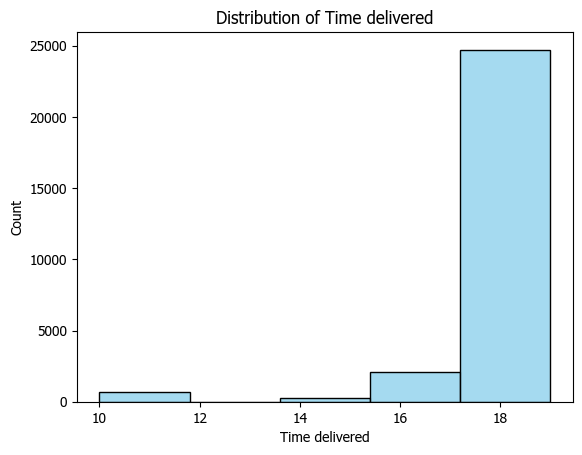

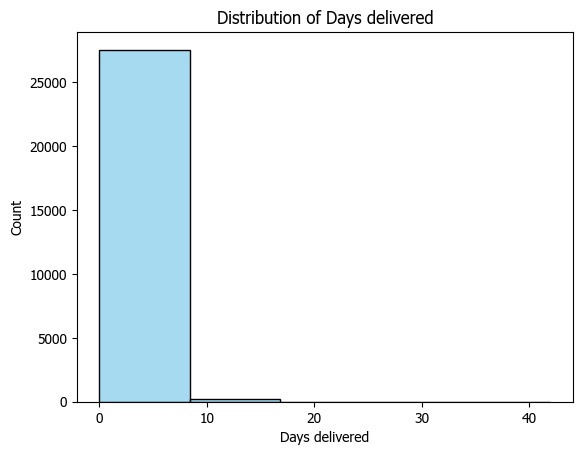

In [43]:
for col in df.select_dtypes(include="number").columns.drop("ID"):
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=5, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

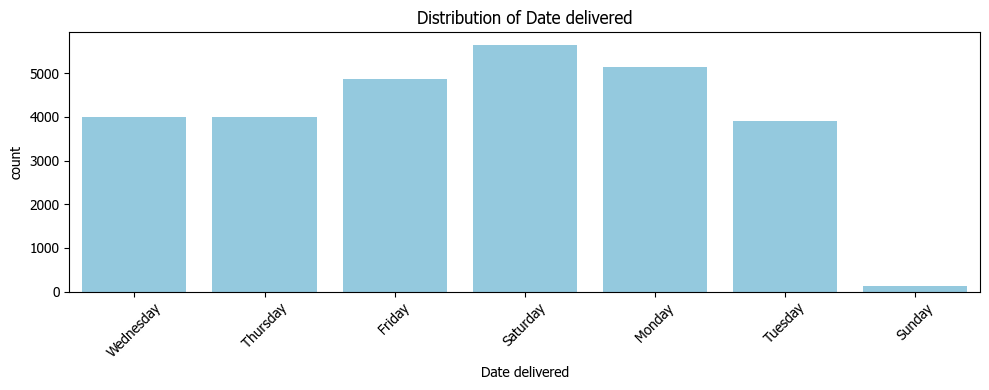

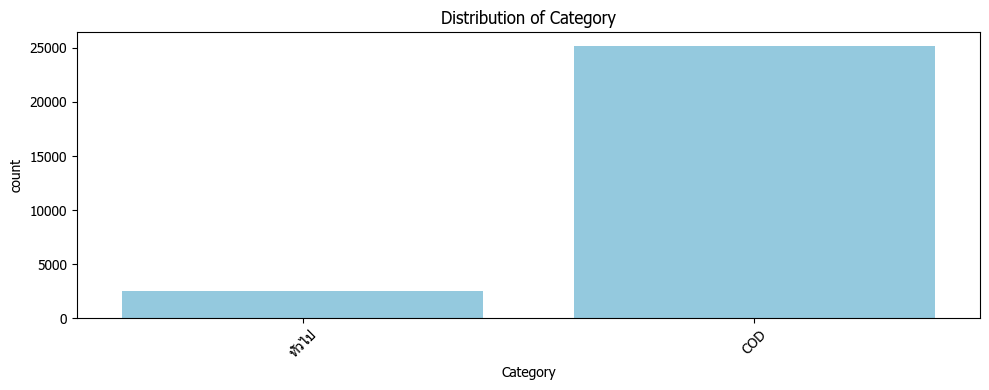

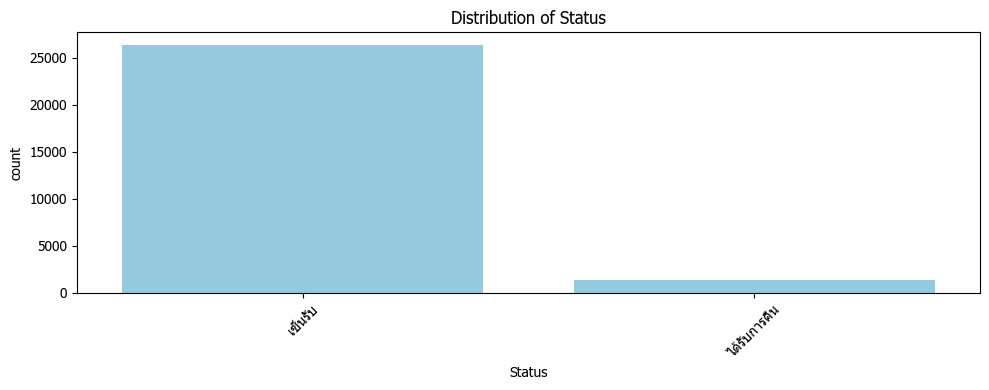

In [44]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]).columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [45]:
crosstab = pd.crosstab(df["Date delivered"], df["Status"])

chi2, p, dof, expected = stats.chi2_contingency(crosstab)

n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

print("--- Contingency Table (Cross Tabulation) ---")
print(crosstab)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

expected_df = pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)")

--- Contingency Table (Cross Tabulation) ---
Status          เซ็นรับ  ได้รับการคืน
Date delivered                       
Friday             4548           321
Monday             4958           193
Saturday           5305           349
Sunday              126             3
Thursday           3827           168
Tuesday            3762           148
Wednesday          3858           151

--- Chi-Square Test Results ---
Chi-Square Statistic : 92.8860
p-value              : 0.0000
Degrees of Freedom   : 6
Cramer's V           : 0.0579

--- Assumption Check ---
Total Cells: 14
Cells with Expected Value < 5: 0 (0.00%)


In [46]:
crosstab = pd.crosstab(df["Time delivered"], df["Status"])

chi2, p, dof, expected = stats.chi2_contingency(crosstab)

n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

print("--- Contingency Table (Cross Tabulation) ---")
print(crosstab)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

expected_df = pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)")

--- Contingency Table (Cross Tabulation) ---
Status          เซ็นรับ  ได้รับการคืน
Time delivered                       
10                  559            89
13                    1             0
15                  271            11
16                  149             4
17                 1809           103
18                17387           786
19                 6208           340

--- Chi-Square Test Results ---
Chi-Square Statistic : 127.7253
p-value              : 0.0000
Degrees of Freedom   : 6
Cramer's V           : 0.0679

--- Assumption Check ---
Total Cells: 14
Cells with Expected Value < 5: 2 (14.29%)


In [47]:
# 1. ฟังก์ชันสําหรับยุบกลุ่มช่วงเวลา (Time Delivered Binning)
def group_time(hour):
    if hour == 10:
        return "1. ช่วงสาย (10:00)"
    elif hour in [13, 15, 16, 17]:
        return "2. ช่วงบ่าย (13:00 - 17:59)"
    elif hour in [18, 19]:
        return "3. ช่วงเย็น/ค่ำ (18:00 - 19:59)"
    else:
        return "4. อื่นๆ"


# แปลงค่าในคอลัมน์เดิมให้กลายเป็นกลุ่มใหม่
df["Time_Grouped"] = df["Time delivered"].apply(group_time)

# 2. สร้างตารางไขว้ (Crosstab) จากกลุ่มใหม่
crosstab_new = pd.custom = pd.crosstab(df["Time_Grouped"], df["Status"])

# 3. คำนวณ Chi-Square
chi2, p, dof, expected = stats.chi2_contingency(crosstab_new)

# 4. คำนวณ Cramer's V
n = crosstab_new.sum().sum()
min_dim = min(crosstab_new.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

# 5. แสดงผลลัพธ์
print("--- New Contingency Table (Grouped) ---")
print(crosstab_new)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

# 6. ตรวจสอบเงื่อนไข Assumption หลังจัดกลุ่ม
expected_df = pd.DataFrame(
    expected, index=crosstab_new.index, columns=crosstab_new.columns
)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(
    f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)"
)

--- New Contingency Table (Grouped) ---
Status                           เซ็นรับ  ได้รับการคืน
Time_Grouped                                          
1. ช่วงสาย (10:00)                   559            89
2. ช่วงบ่าย (13:00 - 17:59)         2230           118
3. ช่วงเย็น/ค่ำ (18:00 - 19:59)    23595          1126

--- Chi-Square Test Results ---
Chi-Square Statistic : 116.4924
p-value              : 0.0000
Degrees of Freedom   : 2
Cramer's V           : 0.0648

--- Assumption Check ---
Total Cells: 6
Cells with Expected Value < 5: 0 (0.00%)


In [48]:
crosstab = pd.crosstab(df["Category"], df["Status"])

chi2, p, dof, expected = stats.chi2_contingency(crosstab)

n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

print("--- Contingency Table (Cross Tabulation) ---")
print(crosstab)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

expected_df = pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)")

--- Contingency Table (Cross Tabulation) ---
Status    เซ็นรับ  ได้รับการคืน
Category                       
COD         23865          1325
ทั่วไป       2519             8

--- Chi-Square Test Results ---
Chi-Square Statistic : 121.5162
p-value              : 0.0000
Degrees of Freedom   : 1
Cramer's V           : 0.0662

--- Assumption Check ---
Total Cells: 4
Cells with Expected Value < 5: 0 (0.00%)


In [49]:
crosstab = pd.crosstab(df["Days delivered"], df["Status"])

chi2, p, dof, expected = stats.chi2_contingency(crosstab)

n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

print("--- Contingency Table (Cross Tabulation) ---")
print(crosstab)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

expected_df = pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)")

--- Contingency Table (Cross Tabulation) ---
Status          เซ็นรับ  ได้รับการคืน
Days delivered                       
0                     0             1
1                 12883             0
2                  9815             4
3                  2257            91
4                   716           263
5                   384           262
6                   159           269
7                    81           204
8                    41           102
9                    20            67
10                    7            26
11                    1            16
12                    3            12
13                    1            10
14                    3             2
15                    1             2
16                    3             0
17                    3             0
18                    2             1
19                    1             0
20                    0             1
21                    2             0
42                    1             0

--- 

In [50]:
def group_days(days):
    if days == 1:
        return "1. ส่งใน 1 วัน (Next Day)"
    elif days == 2:
        return "2. ส่งใน 2 วัน (Standard)"
    elif days in [3, 4, 5]:
        return "3. ส่งใน 3-5 วัน (Delayed)"
    else:
        return "4. ส่งมากกว่า 5 วัน (Severe Delay)"


# แปลงกลุ่มและรันใหม่
df["Days_Grouped"] = df["Days delivered"].apply(group_days)
crosstab_days = pd.crosstab(df["Days_Grouped"], df["Status"])

# 🛠️ จุดแก้ไขที่ 1: เปลี่ยนจาก crosstab เป็น crosstab_days
chi2, p, dof, expected = stats.chi2_contingency(crosstab_days)

# 🛠️ จุดแก้ไขที่ 2: เปลี่ยนจาก crosstab เป็น crosstab_days เพื่อหา Cramer's V ให้ถูกตาราง
n = crosstab_days.sum().sum()
min_dim = min(crosstab_days.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

print("--- Contingency Table (Cross Tabulation) ---")
print(crosstab_days)  # 🛠️ จุดแก้ไข: ปริ้นตารางใหม่ที่จัดกลุ่มแล้ว
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

# 🛠️ จุดแก้ไขที่ 3: ดึง index และ columns จาก crosstab_days
expected_df = pd.DataFrame(
    expected, index=crosstab_days.index, columns=crosstab_days.columns
)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(
    f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)"
)

--- Contingency Table (Cross Tabulation) ---
Status                              เซ็นรับ  ได้รับการคืน
Days_Grouped                                             
1. ส่งใน 1 วัน (Next Day)             12883             0
2. ส่งใน 2 วัน (Standard)              9815             4
3. ส่งใน 3-5 วัน (Delayed)             3357           616
4. ส่งมากกว่า 5 วัน (Severe Delay)      329           713

--- Chi-Square Test Results ---
Chi-Square Statistic : 11342.8812
p-value              : 0.0000
Degrees of Freedom   : 3
Cramer's V           : 0.6397

--- Assumption Check ---
Total Cells: 8
Cells with Expected Value < 5: 0 (0.00%)


In [51]:
# 1. แยกข้อมูลจำนวนวันจัดส่งออกเป็น 2 กลุ่มตามสถานะ Status
group_success = df[df["Status"] == "เซ็นรับ"]["Days delivered"].dropna()
group_return = df[df["Status"] == "ได้รับการคืน"]["Days delivered"].dropna()

# 2. เช็คความเบ้ (Skewness) เพื่อดูหน้าตาข้อมูลก่อนเลือกสถิติ
skew_success = stats.skew(group_success)
skew_return = stats.skew(group_return)

# 3. คำนวณสถิติ Parametric (Independent t-test)
t_stat, t_p = stats.ttest_ind(group_success, group_return, equal_var=False)

# 4. คำนวณสถิติ Non-parametric (Mann-Whitney U Test)
u_stat, u_p = stats.mannwhitneyu(
    group_success, group_return, alternative="two-sided"
)

# 5. แสดงผลลัพธ์
print("--- Descriptive Statistics by Group ---")
print(
    f"กลุ่มเซ็นรับ      -> Mean: {group_success.mean():.2f} วัน | Median: {group_success.median():.2f} วัน | Skewness: {skew_success:.2f}"
)
print(
    f"กลุ่มได้รับการคืน  -> Mean: {group_return.mean():.2f} วัน | Median: {group_return.median():.2f} วัน | Skewness: {skew_return:.2f}"
)

print("\n--- Test 1: Independent t-test (Parametric) ---")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {t_p:.4f}")

print("\n--- Test 2: Mann-Whitney U Test (Non-parametric) ---")
print(f"U-statistic : {u_stat:.4f}")
print(f"p-value     : {u_p:.4f}")

--- Descriptive Statistics by Group ---
กลุ่มเซ็นรับ      -> Mean: 1.76 วัน | Median: 2.00 วัน | Skewness: 5.17
กลุ่มได้รับการคืน  -> Mean: 5.93 วัน | Median: 6.00 วัน | Skewness: 1.26

--- Test 1: Independent t-test (Parametric) ---
t-statistic : -72.3877
p-value     : 0.0000

--- Test 2: Mann-Whitney U Test (Non-parametric) ---
U-statistic : 816146.0000
p-value     : 0.0000


In [52]:
# 1. แยกข้อมูลจำนวนวันจัดส่งออกเป็น 2 กลุ่มตามสถานะ Status
group_success = df[df["Status"] == "เซ็นรับ"]["Days delivered"].dropna()
group_return = df[df["Status"] == "ได้รับการคืน"]["Days delivered"].dropna()

# 2. เช็คความเบ้ (Skewness)
skew_success = stats.skew(group_success)
skew_return = stats.skew(group_return)

# 3. คำนวณสถิติ Parametric (Independent t-test) และ Cohen's d
t_stat, t_p = stats.ttest_ind(group_success, group_return, equal_var=False)
n1, n2 = len(group_success), len(group_return)
pooled_std = np.sqrt(
    ((n1 - 1) * group_success.var() + (n2 - 1) * group_return.var())
    / (n1 + n2 - 2)
)
cohens_d = (group_success.mean() - group_return.mean()) / pooled_std

# 4. คำนวณสถิติ Non-parametric (Mann-Whitney U Test) และ Rank-Biserial Correlation
u_stat, u_p = stats.mannwhitneyu(
    group_success, group_return, alternative="two-sided"
)
# คำนวณ Rank-Biserial Correlation (r) จากค่า U
rank_biserial_r = 1 - (2 * u_stat) / (n1 * n2)

# 5. แสดงผลลัพธ์
print("=========================================================")
print(" 1. สถิติพรรณนาเปรียบเทียบกลุ่ม (Descriptive Statistics)")
print("=========================================================")
print(
    f"กลุ่มเซ็นรับ      -> จำนวน: {n1:,} ราย | Mean: {group_success.mean():.2f} วัน | Median: {group_success.median():.2f} วัน | Skewness: {skew_success:.2f}"
)
print(
    f"กลุ่มได้รับการคืน  -> จำนวน: {n2:,} ราย | Mean: {group_return.mean():.2f} วัน | Median: {group_return.median():.2f} วัน | Skewness: {skew_return:.2f}"
)

print("\n=========================================================")
print(" 2. การเปรียบเทียบด้วยสถิติทดสอบและขนาดอิทธิพล (Effect Size)")
print("=========================================================")
print("[สาย Parametric - อิงค่าเฉลี่ย]")
print(f"t-statistic                 : {t_stat:.4f}")
print(f"p-value                     : {t_p:.4f}")
print(f"Cohen's d (ขนาดอิทธิพล)       : {cohens_d:.4f} (ค่าวิเคราะห์ระยะห่างของ Mean)")

print("\n[สาย Non-parametric - อิงอันดับ/มัธยฐาน] **แนะนำให้ใช้ตัวนี้**")
print(f"U-statistic                 : {u_stat:.4f}")
print(f"p-value                     : {u_p:.4f}")
print(
    f"Rank-Biserial r (ขนาดอิทธิพล): {rank_biserial_r:.4f} (ค่าความสัมพันธ์ของอันดับวัน)"
)
print("=========================================================")

 1. สถิติพรรณนาเปรียบเทียบกลุ่ม (Descriptive Statistics)
กลุ่มเซ็นรับ      -> จำนวน: 26,384 ราย | Mean: 1.76 วัน | Median: 2.00 วัน | Skewness: 5.17
กลุ่มได้รับการคืน  -> จำนวน: 1,333 ราย | Mean: 5.93 วัน | Median: 6.00 วัน | Skewness: 1.26

 2. การเปรียบเทียบด้วยสถิติทดสอบและขนาดอิทธิพล (Effect Size)
[สาย Parametric - อิงค่าเฉลี่ย]
t-statistic                 : -72.3877
p-value                     : 0.0000
Cohen's d (ขนาดอิทธิพล)       : -3.5271 (ค่าวิเคราะห์ระยะห่างของ Mean)

[สาย Non-parametric - อิงอันดับ/มัธยฐาน] **แนะนำให้ใช้ตัวนี้**
U-statistic                 : 816146.0000
p-value                     : 0.0000
Rank-Biserial r (ขนาดอิทธิพล): 0.9536 (ค่าความสัมพันธ์ของอันดับวัน)


In [53]:
df.head()

,ID,Date delivered,Time delivered,Category,Days delivered,Status,Time_Grouped,Days_Grouped
0,66850940174727,Wednesday,18,ทั่วไป,2,เซ็นรับ,3. ช่วงเย็น/ค่ำ (18:00 - 19:59),2. ส่งใน 2 วัน (Standard)
1,66850940174732,Wednesday,18,ทั่วไป,1,เซ็นรับ,3. ช่วงเย็น/ค่ำ (18:00 - 19:59),1. ส่งใน 1 วัน (Next Day)
2,66850940174746,Wednesday,18,COD,7,ได้รับการคืน,3. ช่วงเย็น/ค่ำ (18:00 - 19:59),4. ส่งมากกว่า 5 วัน (Severe Delay)
3,66850940174751,Wednesday,18,COD,1,เซ็นรับ,3. ช่วงเย็น/ค่ำ (18:00 - 19:59),1. ส่งใน 1 วัน (Next Day)
4,66850940174765,Wednesday,18,COD,2,เซ็นรับ,3. ช่วงเย็น/ค่ำ (18:00 - 19:59),2. ส่งใน 2 วัน (Standard)


In [54]:
df['Return_Flag'] = df['Status'].map({
    'เซ็นรับ': 0,
    'ได้รับการคืน': 1
})

In [55]:
X = [
    'Days delivered',
    'Hour',
    'Category',
    'Day Name'
]

In [56]:
df = df.rename(columns={
    'Day Name': 'Day_Name',
    'Days delivered': 'Days_delivered',
    'Date delivered': 'Weekday'
})

In [57]:
print(df.columns.tolist())

['ID', 'Weekday', 'Time delivered', 'Category', 'Days_delivered', 'Status', 'Time_Grouped', 'Days_Grouped', 'Return_Flag']


In [58]:
import statsmodels.formula.api as smf

model = smf.logit(
    'Return_Flag ~ Days_delivered + C(Category) + C(Time_Grouped)',
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.093144
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:            Return_Flag   No. Observations:                27717
Model:                          Logit   Df Residuals:                    27712
Method:                           MLE   Df Model:                            4
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                  0.5170
Time:                        03:18:05   Log-Likelihood:                -2581.7
converged:                       True   LL-Null:                       -5345.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                  

In [59]:
import pandas as pd
import numpy as np

or_table = pd.DataFrame({
    'Variable': model.params.index,
    'Coef': model.params,
    'Odds_Ratio': np.exp(model.params),
    'P_Value': model.pvalues
})

or_table = or_table.sort_values('P_Value')

print(or_table)

                                                                                             Variable  \
Days_delivered                                                                         Days_delivered   
Intercept                                                                                   Intercept   
C(Category)[T.ทั่วไป]                                                           C(Category)[T.ทั่วไป]   
C(Time_Grouped)[T.3. ช่วงเย็น/ค่ำ (18:00 - 19:59)]  C(Time_Grouped)[T.3. ช่วงเย็น/ค่ำ (18:00 - 19:...   
C(Time_Grouped)[T.2. ช่วงบ่าย (13:00 - 17:59)]         C(Time_Grouped)[T.2. ช่วงบ่าย (13:00 - 17:59)]   

                                                        Coef  Odds_Ratio  \
Days_delivered                                      1.132960    3.104834   
Intercept                                          -6.125844    0.002186   
C(Category)[T.ทั่วไป]                              -3.235931    0.039324   
C(Time_Grouped)[T.3. ช่วงเย็น/ค่ำ (18:00 - 19:59)] -0.420436    0

In [60]:
import statsmodels.formula.api as smf

model_final = smf.logit(
    'Return_Flag ~ Days_delivered + C(Category) + C(Weekday)',
    data=df
).fit()

print(model_final.summary())

Optimization terminated successfully.
         Current function value: 0.092563
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:            Return_Flag   No. Observations:                27717
Model:                          Logit   Df Residuals:                    27708
Method:                           MLE   Df Model:                            8
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                  0.5201
Time:                        03:18:05   Log-Likelihood:                -2565.6
converged:                       True   LL-Null:                       -5345.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -6.2974      0.117    -53.731      0.000      -6.527  

In [ ]:
import pandas as pd
from itertools import product

days = [1, 3, 5, 7]
categories = ['ทั่วไป', 'COD']
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

test_cases = pd.DataFrame(
    list(product(days, categories, weekdays)),
    columns=['Days_delivered', 'Category', 'Weekday']
)

test_cases['Return_Probability'] = model_final.predict(test_cases)

test_cases['Return_%'] = (test_cases['Return_Probability'] * 100).round(2)

print(test_cases)

    Days_delivered Category    Weekday  Return_Probability  Return_%
0                1   ทั่วไป     Monday            0.000117      0.01
1                1   ทั่วไป    Tuesday            0.000144      0.01
2                1   ทั่วไป  Wednesday            0.000143      0.01
3                1   ทั่วไป   Thursday            0.000116      0.01
4                1   ทั่วไป     Friday            0.000202      0.02
5                1      COD     Monday            0.003322      0.33
6                1      COD    Tuesday            0.004083      0.41
7                1      COD  Wednesday            0.004036      0.40
8                1      COD   Thursday            0.003296      0.33
9                1      COD     Friday            0.005714      0.57
10               3   ทั่วไป     Monday            0.001142      0.11
11               3   ทั่วไป    Tuesday            0.001404      0.14
12               3   ทั่วไป  Wednesday            0.001388      0.14
13               3   ทั่วไป   Thur